<a href="https://colab.research.google.com/github/iamdreams1/Group_051_-COMP90042_Project_2026/blob/main/Group_051__COMP90042_Project_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2026 COMP90042 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

# 1.DataSet Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [1]:
# 1.1 路径与设备配置（团队协作：Colab 走 Drive shortcut，本地走相对路径）
#
# 设计：
#   - Colab : ROOT = /content/drive/MyDrive/comp90042
#             （团队成员对该文件夹做了 shortcut，所以每个人 MyDrive 下都能看到）
#   - 本地  : ROOT = notebook 所在目录的绝对路径
#             （队友只要 clone 仓库，data/ 和 cache/ 平级即可，不用改代码）
#   - 任何人都可以用 COMP90042_ROOT 环境变量覆盖，方便挪盘
import os, sys, torch

IN_COLAB = 'google.colab' in sys.modules

# 1) 优先读环境变量（最高优先级，任何人想挪到 SSD/外接盘 export 一下就行）
ROOT = os.environ.get('COMP90042_ROOT')

# 2) Colab：挂 Drive 后用团队约定的 shortcut 路径
if ROOT is None and IN_COLAB:
    from google.colab import drive
    if not os.path.isdir('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/comp90042'

# 3) 本地：相对当前工作目录（在 notebook 同级目录启动 jupyter 即可）
if ROOT is None:
    ROOT = os.path.abspath(os.getcwd())

DATA  = os.path.join(ROOT, 'data')
CACHE = os.path.join(ROOT, 'cache')
CKPT  = os.path.join(ROOT, 'ckpt')
for p in (CACHE, CKPT):
    os.makedirs(p, exist_ok=True)

# 设备选择：cuda > mps > cpu
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print(f'IN_COLAB : {IN_COLAB}')
print(f'ROOT     : {ROOT}')
print(f'DEVICE   : {DEVICE}')
print(f'DATA     : {DATA}')
print(f'CACHE    : {CACHE}')


IN_COLAB : False
ROOT     : /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026
DEVICE   : mps
DATA     : /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/data
CACHE    : /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/cache


In [2]:
# 1.1.b 数据就位检查（团队共享 cache：避免每人重新跑重型步骤）
#
# 这一步只做“文件是否就位”的快速检查，不加载大对象。
# 真正加载/校验由后面的 cache helper 统一处理。
import os

REQUIRED = {
    'data/train-claims.json'           : True,
    'data/dev-claims.json'             : True,
    'data/test-claims-unlabelled.json' : True,
    'data/evidence.json'               : True,
}

OFFICIAL_CACHE = {
    'cache/evidence.pkl'          : 'raw evidence pickle',
    'cache/evidence_filtered.pkl' : 'filtered evidence dict + ids',
    'cache/bm25.pkl'              : 'BM25Okapi index',
    'cache/bge_evidence_emb.npy'  : 'BGE evidence embeddings',
    'cache/bge_faiss.index'       : 'FAISS dense index',
    'cache/retrieval_eval_dev.pkl': 'A1 retrieval Recall@K table',
    'cache/hybrid_dev.pkl'        : 'hybrid dev candidates',
    'cache/hybrid_train.pkl'      : 'hybrid train candidates',
    'cache/hybrid_test.pkl'       : 'hybrid test candidates',
    'cache/bm25_dev.pkl'           : 'bm25 dev candidates (baseline)',
    'cache/bm25_train.pkl'         : 'bm25 train candidates (baseline)',
    'cache/bm25_test.pkl'          : 'bm25 test candidates (baseline)',
}

print(f'检查 ROOT = {ROOT}')
print('-' * 70)
missing_required = []
for rel, required in REQUIRED.items():
    p = os.path.join(ROOT, rel)
    if os.path.exists(p):
        print(f'  ok {rel:<42s} {os.path.getsize(p)/1e6:>8.1f} MB')
    else:
        print(f'  MISSING {rel}')
        if required:
            missing_required.append(rel)

if missing_required:
    raise FileNotFoundError(
        f'缺少必需文件: {missing_required}\n'
        f'请确认 Drive shortcut 已生效，或在本地把 data/ 放到 {ROOT} 下。'
    )
print('-' * 70)
print('必需数据已就位')

print('\n官方 cache 快速检查（存在不代表有效，后面会逐项校验）')
print('-' * 70)
missing_cache = []
for rel, desc in OFFICIAL_CACHE.items():
    p = os.path.join(ROOT, rel)
    if os.path.exists(p):
        print(f'  ok {rel:<34s} {os.path.getsize(p)/1e6:>8.1f} MB  ({desc})')
    else:
        print(f'  missing {rel:<34s} ({desc})')
        missing_cache.append(rel)

HYBRID_CACHE_RELS = ['cache/hybrid_dev.pkl', 'cache/hybrid_train.pkl', 'cache/hybrid_test.pkl']
BM25_CACHE_RELS   = ['cache/bm25_dev.pkl',   'cache/bm25_train.pkl',   'cache/bm25_test.pkl']
ALL_HYBRID_FILES_PRESENT = all(os.path.exists(os.path.join(ROOT, rel)) for rel in HYBRID_CACHE_RELS)
ALL_BM25_FILES_PRESENT   = all(os.path.exists(os.path.join(ROOT, rel)) for rel in BM25_CACHE_RELS)
print('\nFast-path summary:')
print(f'  hybrid candidate files present : {ALL_HYBRID_FILES_PRESENT}')
print(f'  bm25 candidate files present   : {ALL_BM25_FILES_PRESENT}')


检查 ROOT = /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026
----------------------------------------------------------------------
  ok data/train-claims.json                          0.3 MB
  ok data/dev-claims.json                            0.0 MB
  ok data/test-claims-unlabelled.json                0.0 MB
  ok data/evidence.json                            174.2 MB
----------------------------------------------------------------------
必需数据已就位

官方 cache 快速检查（存在不代表有效，后面会逐项校验）
----------------------------------------------------------------------
  ok cache/evidence.pkl                    170.5 MB  (raw evidence pickle)
  ok cache/evidence_filtered.pkl           188.6 MB  (filtered evidence dict + ids)
  ok cache/bm25.pkl                        190.0 MB  (BM25Okapi index)
  ok cache/bge_evidence_emb.npy           3713.5 MB  (BGE evidence embeddings)
  ok cache/bge_faiss.index                3713.5 MB  (FAISS dense index)
  ok cache/retrieval_eva

In [3]:
# 1.2 NLTK 资源（如果是 Colab 第一次跑，取消下面 pip 注释）
!pip install -q rank_bm25 sentencepiece protobuf tiktoken transformers==4.40.0 nltk pandas matplotlib scikit-learn

import importlib.util
import nltk

for module_name in ['sentencepiece', 'transformers', 'tokenizers']:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f'{module_name} 未安装成功；请重新运行本 cell，必要时 Runtime > Restart runtime 后再 Run all')

def ensure_nltk_resource(pkg, path, required=True):
    try:
        nltk.data.find(path)
    except (LookupError, OSError):
        ok = nltk.download(pkg, quiet=True)
        if required and not ok:
            raise RuntimeError(f'下载 NLTK 资源 {pkg} 失败')

ensure_nltk_resource('punkt',      'tokenizers/punkt')
ensure_nltk_resource('punkt_tab',  'tokenizers/punkt_tab', required=False)  # 新版 nltk 才有
ensure_nltk_resource('stopwords',  'corpora/stopwords')
print('✓ tokenizer 依赖就绪（sentencepiece / transformers / tokenizers）')
print('✓ NLTK 资源就绪')


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✓ tokenizer 依赖就绪（sentencepiece / transformers / tokenizers）
✓ NLTK 资源就绪


In [4]:
# 1.2.b Cache helpers（必须先于所有重型 cache 使用）
import os, pickle, gc, time

# Final baseline mode: only BM25 retrieval + DeBERTa classifier is used for eval.
# Old BGE/hybrid exploration code is kept below but disabled by default.
RUN_HYBRID_EXPERIMENTS = False

FORCE_REBUILD = {
    'filtered': False,
    'bm25': False,
    'bge': False,
    'eval': False,
    'hybrid': False,
}

CACHE_META = {
    'filtered': {
        'version': 1,
        'max_words': 256,
        'min_words_threshold': 3,
    },
    'bm25': {
        'version': 1,
        'tokenizer': 'nltk_word_tokenize_lower_stopwords_punct_isalnum_v1',
        'max_words': 256,
        'min_words_threshold': 3,
    },
    'bge': {
        'version': 1,
        'model': 'BAAI/bge-base-en-v1.5',
        'max_seq_len': 384,
        'embedding_dim': 768,
    },
    'hybrid': {
        'version': 2,
        'k_each': 200,
        'mode': 'rrf_v1',
        'rrf_k': 60,
    },
}


def save_pickle_atomic(data, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    tmp = path + '.tmp'
    with open(tmp, 'wb') as f:
        pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, path)


def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def release_large_objects(*names):
    released = []
    for name in names:
        if name in globals():
            del globals()[name]
            released.append(name)
    if released:
        gc.collect()
        if 'torch' in globals() and getattr(torch, 'cuda', None) and torch.cuda.is_available():
            torch.cuda.empty_cache()
        print('released:', ', '.join(released))


def validate_candidate_cache(data, claims, name='cache', max_len=None, known_evidence=None):
    if not isinstance(data, dict):
        return False, f'{name} is not a dict'
    expected = set(claims.keys())
    actual = set(data.keys())
    missing = expected - actual
    extra = actual - expected
    if missing or extra:
        return False, f'{name} claim ids mismatch: missing={len(missing)} extra={len(extra)}'
    for cid, vals in data.items():
        if not isinstance(vals, list):
            return False, f'{name}[{cid}] is not a list'
        if max_len is not None and len(vals) > max_len:
            return False, f'{name}[{cid}] has {len(vals)} candidates > {max_len}'
        if len(vals) != len(set(vals)):
            return False, f'{name}[{cid}] contains duplicate evidence ids'
        if known_evidence is not None:
            bad = [eid for eid in vals if eid not in known_evidence]
            if bad:
                return False, f'{name}[{cid}] contains unknown evidence id {bad[0]}'
    return True, 'ok'


def load_candidate_cache(path, claims, name='cache', max_len=None, known_evidence=None, force=False):
    if force or not os.path.exists(path):
        reason = 'forced rebuild' if force else 'missing file'
        print(f'  {name}: {reason}')
        return None
    try:
        t0 = time.time()
        data = load_pickle(path)
        ok, msg = validate_candidate_cache(data, claims, name=name, max_len=max_len, known_evidence=known_evidence)
        if ok:
            avg = sum(len(v) for v in data.values()) / max(1, len(data))
            print(f'  loaded {path} ({len(data)} claims, avg {avg:.0f}, {time.time()-t0:.1f}s)')
            return data
        print(f'  invalid {name}: {msg}; rebuilding')
    except Exception as e:
        print(f'  failed to load {name} ({type(e).__name__}: {e}); rebuilding')
    return None

print('Cache-first helpers ready')
print('FORCE_REBUILD =', FORCE_REBUILD)


Cache-first helpers ready
FORCE_REBUILD = {'filtered': False, 'bm25': False, 'bge': False, 'eval': False, 'hybrid': False}


In [5]:
# 1.3 读取数据
import os, json, pickle, time

os.makedirs(CACHE, exist_ok=True)

def load_json(name):
    with open(f'{DATA}/{name}.json') as f:
        return json.load(f)

t0 = time.time()
train    = load_json('train-claims')
dev      = load_json('dev-claims')
test     = load_json('test-claims-unlabelled')
baseline = load_json('dev-claims-baseline')
print(f'Claims loaded in {time.time()-t0:.1f}s | '
      f'train={len(train)} dev={len(dev)} test={len(test)} baseline={len(baseline)}')

# evidence.json 174MB，首次加载后写入 pickle；后续只读 pickle。
evi_pkl = f'{CACHE}/evidence.pkl'
if os.path.exists(evi_pkl):
    print('从 pickle 缓存加载 evidence ...')
    t0 = time.time()
    evidence = load_pickle(evi_pkl)
    print(f'  loaded in {time.time()-t0:.1f}s | {len(evidence):,} passages')
else:
    print('首次加载 evidence.json (174MB) ...')
    t0 = time.time()
    evidence = load_json('evidence')
    print(f'  loaded in {time.time()-t0:.1f}s | {len(evidence):,} passages')
    save_pickle_atomic(evidence, evi_pkl)
    print(f'  cached -> {evi_pkl}')

evi_ids = list(evidence.keys())
print(f'\n首 3 个 evi_id: {evi_ids[:3]}')
print(f'Evidence corpus 大小: {len(evi_ids):,} passages')


Claims loaded in 0.0s | train=1228 dev=154 test=153 baseline=154
从 pickle 缓存加载 evidence ...
  loaded in 0.3s | 1,208,827 passages

首 3 个 evi_id: ['evidence-0', 'evidence-1', 'evidence-2']
Evidence corpus 大小: 1,208,827 passages


In [6]:
# 1.4 抽样查看一条 train 数据，确认 schema
import random
random.seed(0)

cid = random.choice(list(train.keys()))
sample = train[cid]
print(f'claim_id     : {cid}')
print(f'claim_text   : {sample["claim_text"]}')
print(f'claim_label  : {sample["claim_label"]}')
print(f'gold evi ids : {sample["evidences"]}')
print()
for eid in sample['evidences'][:2]:
    print(f'  [{eid}] {evidence[eid][:200]} ...')

# Test 集对比（无 label / 无 gold evidences）
print()
print('Test 字段（应无 claim_label / evidences）:')
print(f'  {list(next(iter(test.values())).keys())}')

claim_id     : claim-1553
claim_text   : 2009-2010 winter saw record cold spells.
claim_label  : SUPPORTS
gold evi ids : ['evidence-501934']

  [evidence-501934] In Europe, the winters of early 1947, February 1956, 1962–1963, 1981–1982 and 2009–2010 were abnormally cold. ...

Test 字段（应无 claim_label / evidences）:
  ['claim_text']


## 1.5 EDA：长度分布、标签分布、evidence 数

四张图一次出，写报告时直接引用：

| 子图 | 用途 |
|---|---|
| Claim 长度 | 决定 tokenizer max_length（claim 端） |
| 4 类标签分布 | 论证 class weight 必要性，DISPUTED 极少 |
| 每条 claim 的 gold evidence 数 | 决定最终输出 evidence 的 Top-K 大小 |
| Evidence 长度（log scale） | 决定 evidence 端截断策略 |

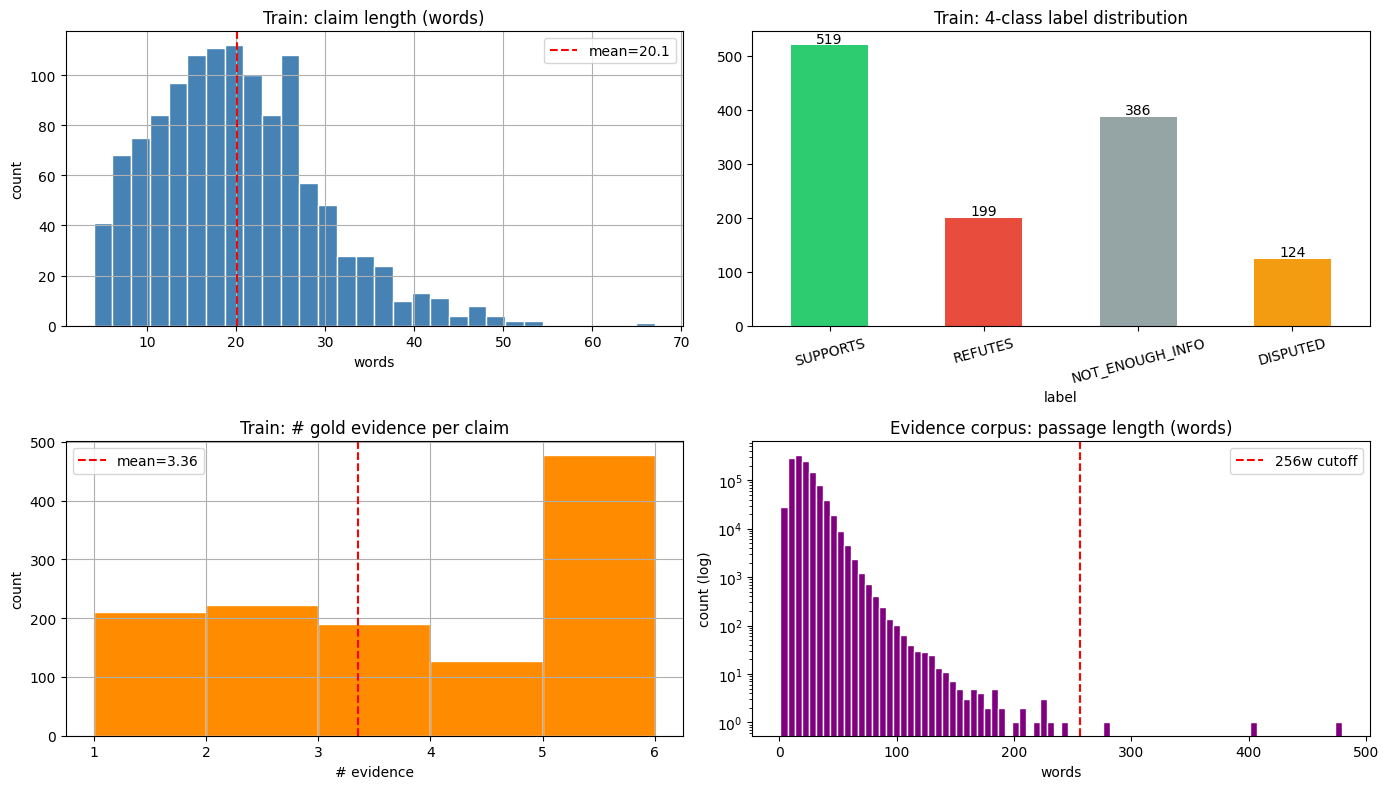

Claim 长度: mean=20.1, p95=37
Gold evidence 数: mean=3.36, p95=5
Evidence 长度: p50=18, p95=39, p99=53, >256w 占比 0.00%


In [7]:
# 1.5 EDA: 4 张子图
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LABELS = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']

# Train claim 维度
df = pd.DataFrame([{
    'claim_len' : len(v['claim_text'].split()),
    'label'     : v['claim_label'],
    'n_evi'     : len(v['evidences']),
} for v in train.values()])

# Evidence 长度（先算一遍，下面要用）
evi_lens = np.array([len(evidence[eid].split()) for eid in evi_ids])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1) claim 长度
df['claim_len'].hist(ax=axes[0,0], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Train: claim length (words)')
axes[0,0].set_xlabel('words'); axes[0,0].set_ylabel('count')
axes[0,0].axvline(df['claim_len'].mean(), color='red', linestyle='--',
                  label=f"mean={df['claim_len'].mean():.1f}")
axes[0,0].legend()

# (2) 4 类标签分布
label_counts = df['label'].value_counts().reindex(LABELS)
label_counts.plot(kind='bar', ax=axes[0,1],
                  color=['#2ecc71','#e74c3c','#95a5a6','#f39c12'])
axes[0,1].set_title('Train: 4-class label distribution')
axes[0,1].set_xticklabels(LABELS, rotation=15)
for i, v in enumerate(label_counts):
    axes[0,1].text(i, v + 5, str(v), ha='center')

# (3) 每条 claim 的 gold evidence 数
n_evi_max = df['n_evi'].max()
df['n_evi'].hist(ax=axes[1,0], bins=range(1, n_evi_max + 2),
                 color='darkorange', edgecolor='white')
axes[1,0].set_title('Train: # gold evidence per claim')
axes[1,0].set_xlabel('# evidence'); axes[1,0].set_ylabel('count')
axes[1,0].axvline(df['n_evi'].mean(), color='red', linestyle='--',
                  label=f"mean={df['n_evi'].mean():.2f}")
axes[1,0].legend()

# (4) Evidence 长度（log y 因为长尾很重）
axes[1,1].hist(evi_lens, bins=80, color='purple', edgecolor='white')
axes[1,1].set_yscale('log')
axes[1,1].set_title('Evidence corpus: passage length (words)')
axes[1,1].set_xlabel('words'); axes[1,1].set_ylabel('count (log)')
axes[1,1].axvline(256, color='red', linestyle='--', label='256w cutoff')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(f'{CACHE}/eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

# 关键数字打印（写报告用）
print(f'Claim 长度: mean={df["claim_len"].mean():.1f}, p95={df["claim_len"].quantile(0.95):.0f}')
print(f'Gold evidence 数: mean={df["n_evi"].mean():.2f}, p95={df["n_evi"].quantile(0.95):.0f}')
print(f'Evidence 长度: p50={int(np.percentile(evi_lens,50))}, '
      f'p95={int(np.percentile(evi_lens,95))}, p99={int(np.percentile(evi_lens,99))}, '
      f'>256w 占比 {(evi_lens > 256).mean()*100:.2f}%')

In [8]:
# 1.6 evidence filtering cache（默认加载 cache/evidence_filtered.pkl）
import time, gc
from collections import Counter

MAX_WORDS = CACHE_META['filtered']['max_words']
MIN_WORDS_THRESHOLD = CACHE_META['filtered']['min_words_threshold']
FILTERED_CACHE = f'{CACHE}/evidence_filtered.pkl'


def validate_filtered_cache(obj):
    if not isinstance(obj, dict):
        return False, 'cache is not a dict'
    required = {'meta', 'evidence_filtered', 'evi_ids_filtered', 'evidence_tags', 'original_count'}
    if not required.issubset(obj):
        return False, f'missing keys: {sorted(required - set(obj))}'
    meta = obj.get('meta', {})
    if meta.get('max_words') != MAX_WORDS or meta.get('min_words_threshold') != MIN_WORDS_THRESHOLD:
        return False, 'filter config mismatch'
    ef = obj['evidence_filtered']
    ids = obj['evi_ids_filtered']
    tags = obj['evidence_tags']
    if not isinstance(ef, dict) or not isinstance(ids, list) or not isinstance(tags, dict):
        return False, 'invalid object types'
    if len(ef) != len(ids) or ids != list(ef.keys()):
        return False, 'filtered evidence id order mismatch'
    return True, 'ok'

loaded_filtered = False
if os.path.exists(FILTERED_CACHE) and not FORCE_REBUILD['filtered']:
    try:
        t0 = time.time()
        obj = load_pickle(FILTERED_CACHE)
        ok, msg = validate_filtered_cache(obj)
        if ok:
            evidence_filtered = obj['evidence_filtered']
            evi_ids_filtered = obj['evi_ids_filtered']
            evidence_tags = obj['evidence_tags']
            original_evidence_count = obj['original_count']
            loaded_filtered = True
            print(f'Loaded filtered evidence cache in {time.time()-t0:.1f}s -> {FILTERED_CACHE}')
        else:
            print(f'Invalid filtered cache: {msg}; rebuilding')
    except Exception as e:
        print(f'Failed to load filtered cache ({type(e).__name__}: {e}); rebuilding')

if not loaded_filtered:
    if 'evidence' not in globals():
        raise RuntimeError('Raw evidence is missing. Run the data loading cell first.')
    t0 = time.time()
    evidence_filtered = {}
    evidence_tags = {}
    for eid, text in evidence.items():
        word_count = len(text.split())
        if word_count > MAX_WORDS:
            continue
        evidence_filtered[eid] = text
        evidence_tags[eid] = 'short' if word_count < MIN_WORDS_THRESHOLD else 'standard'
    evi_ids_filtered = list(evidence_filtered.keys())
    original_evidence_count = len(evidence)
    obj = {
        'meta': dict(CACHE_META['filtered']),
        'evidence_filtered': evidence_filtered,
        'evi_ids_filtered': evi_ids_filtered,
        'evidence_tags': evidence_tags,
        'original_count': original_evidence_count,
    }
    save_pickle_atomic(obj, FILTERED_CACHE)
    print(f'Built filtered evidence in {time.time()-t0:.1f}s -> {FILTERED_CACHE}')

print(f'Original passages: {original_evidence_count:,}')
print(f'Remaining passages: {len(evidence_filtered):,}')
print(f'Removed (Too Long): {original_evidence_count - len(evidence_filtered):,}')
print(f"Tagged as 'Short':   {list(evidence_tags.values()).count('short'):,}")

# 后续只需要 filtered corpus；释放 raw evidence 降低 Colab RAM 峰值。
release_large_objects('evidence', 'evi_ids')


Loaded filtered evidence cache in 0.4s -> /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/cache/evidence_filtered.pkl
Original passages: 1,208,827
Remaining passages: 1,208,824
Removed (Too Long): 3
Tagged as 'Short':   1,789
released: evidence, evi_ids


In [9]:
train_pairs = []

# Process all claims in train-claims.json
for cid, data in train.items():
    label = data['claim_label']
    claim_text = data['claim_text']
    gold_ids = data.get('evidences', [])

    for eid in gold_ids:
        # Check if the evidence exists in our filtered dictionary
        if eid in evidence_filtered:
            train_pairs.append({
                "claim": claim_text,
                "evidence": evidence_filtered[eid],
                "label": label,
                "claim_id": cid,
                "evidence_id": eid
            })

print(f"Total training pairs generated: {len(train_pairs):,}")

Total training pairs generated: 4,121


# 2.Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [10]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

nltk.download('punkt')
nltk.download('stopwords')

# Pre-loading stopwords and punctuation for speed
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/lizhenxiang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lizhenxiang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
def nltk_tokenize(text):
    # Standard NLTK tokenization
    tokens = word_tokenize(text.lower())

    # Filter out stopwords and punctuation to keep the index clean
    # and improve retrieval relevance for scientific terms
    filtered = [
        t for t in tokens
        if t not in stop_words and t not in punctuation and t.isalnum()
    ]
    return filtered

In [12]:
# 2.1 BM25 cache（默认加载 cache/bm25.pkl；缺失或无效才重建）
import time, gc
from rank_bm25 import BM25Okapi
from tqdm.auto import tqdm

BM25_CACHE = f'{CACHE}/bm25.pkl'
BM25_META = dict(CACHE_META['bm25'])


def unpack_bm25_cache(obj):
    # New format: {'meta': ..., 'bm25': ..., 'evi_ids_filtered': ...}
    if isinstance(obj, dict) and {'bm25', 'evi_ids_filtered'}.issubset(obj):
        return obj.get('bm25'), obj.get('evi_ids_filtered'), obj.get('meta'), False
    # Backward-compatible legacy format already used by this project: (bm25, ids)
    if isinstance(obj, tuple) and len(obj) == 2:
        return obj[0], obj[1], None, True
    return None, None, None, False


def validate_bm25_cache(obj):
    cached_bm25, cached_ids, meta, legacy = unpack_bm25_cache(obj)
    if cached_bm25 is None or cached_ids is None:
        return False, 'unrecognized BM25 cache format', None
    if list(cached_ids) != list(evi_ids_filtered):
        return False, 'evidence id order mismatch', None
    if getattr(cached_bm25, 'corpus_size', None) != len(evi_ids_filtered):
        return False, 'BM25 corpus size mismatch', None
    if meta is not None and meta != BM25_META:
        return False, 'BM25 tokenizer/filter metadata mismatch', None
    if legacy:
        print('  note: legacy BM25 cache has no metadata; accepted after id-order and corpus-size checks')
    return True, 'ok', cached_bm25


def build_bm25_cache():
    print('Tokenizing filtered evidence with NLTK... (only runs on cache miss/force rebuild)')
    t0 = time.time()
    corpus_tokens = []
    for eid in tqdm(evi_ids_filtered, desc='BM25 tokenize'):
        corpus_tokens.append(nltk_tokenize(evidence_filtered[eid]))
    print(f'Tokenization finished in {time.time()-t0:.1f}s')

    print('Building BM25Okapi index...')
    t0 = time.time()
    built_bm25 = BM25Okapi(corpus_tokens)
    del corpus_tokens
    gc.collect()
    print(f'BM25 built in {time.time()-t0:.1f}s')

    save_pickle_atomic({
        'meta': BM25_META,
        'bm25': built_bm25,
        'evi_ids_filtered': list(evi_ids_filtered),
    }, BM25_CACHE)
    print(f'BM25 cache saved -> {BM25_CACHE}')
    return built_bm25

bm25 = None
if os.path.exists(BM25_CACHE) and not FORCE_REBUILD['bm25']:
    try:
        t0 = time.time()
        obj = load_pickle(BM25_CACHE)
        ok, msg, loaded_bm25 = validate_bm25_cache(obj)
        if ok:
            bm25 = loaded_bm25
            print(f'BM25 loaded from cache in {time.time()-t0:.1f}s -> {BM25_CACHE}')
        else:
            print(f'Invalid BM25 cache: {msg}; rebuilding')
    except Exception as e:
        print(f'Failed to load BM25 cache ({type(e).__name__}: {e}); rebuilding')

if bm25 is None:
    bm25 = build_bm25_cache()


BM25 loaded from cache in 1.1s -> /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/cache/bm25.pkl


In [13]:
def get_top_200(claim_text, n=200):
    required = ['bm25', 'evi_ids_filtered', 'evidence_filtered', 'nltk_tokenize']
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(
            'Missing prerequisites: ' + ', '.join(missing) +
            '. Run data filtering, tokenizer setup, and BM25 cache cells first.'
        )

    query_tokens = nltk_tokenize(claim_text)
    scores = bm25.get_scores(query_tokens)

    import numpy as np
    n = max(1, min(n, len(scores)))
    top_indices = np.argsort(scores)[-n:][::-1]

    results = []
    for idx in top_indices:
        eid = evi_ids_filtered[idx]
        results.append({
            'id': eid,
            'text': evidence_filtered[eid],
            'score': float(scores[idx]),
        })
    return results

# Lightweight smoke test: BM25 only, no dense/BGE objects involved.
if 'train' not in globals() or len(train) == 0:
    raise RuntimeError('`train` is missing or empty. Please run data loading cell first.')

example_cid = 'claim-1937' if 'claim-1937' in train else next(iter(train))
example_claim = train[example_cid]['claim_text']
top_evidences = get_top_200(example_claim)
print(f'Example claim ID: {example_cid}')
print(f"Top result ID: {top_evidences[0]['id']}")


Example claim ID: claim-1937
Top result ID: evidence-66273


In [14]:
# 2.2 Dense retrieval dependencies（baseline-only 默认跳过 BGE/FAISS）
import importlib.util, subprocess, sys, os

EVAL_CACHE_PATH = f'{CACHE}/retrieval_eval_dev.pkl'
HYBRID_CACHE_PATHS = {
    'dev': f'{CACHE}/hybrid_dev.pkl',
    'train': f'{CACHE}/hybrid_train.pkl',
    'test': f'{CACHE}/hybrid_test.pkl',
}

NEED_DENSE_DEPS = RUN_HYBRID_EXPERIMENTS and (
    FORCE_REBUILD['bge'] or
    FORCE_REBUILD['hybrid'] or
    FORCE_REBUILD['eval'] or
    (not os.path.exists(EVAL_CACHE_PATH)) or
    any(not os.path.exists(p) for p in HYBRID_CACHE_PATHS.values())
)

if NEED_DENSE_DEPS and importlib.util.find_spec('faiss') is None:
    print('Installing faiss-cpu because dense retrieval may be needed...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'faiss-cpu'])
else:
    print(f'Dense dependency check complete. NEED_DENSE_DEPS={NEED_DENSE_DEPS}')


Dense dependency check complete. NEED_DENSE_DEPS=False


In [15]:
# 2.x Optional BGE / FAISS dense retrieval（baseline-only 路线不使用）
import os, gc, time, math
import numpy as np
import torch

CHUNK_SIZE  = 50_000
MAX_SEQ_LEN = CACHE_META['bge']['max_seq_len']
SORT_BY_LEN = True

CHUNK_DIR  = f'{CACHE}/bge_chunks'
EMB_FINAL  = f'{CACHE}/bge_evidence_emb.npy'
ORDER_FILE = f'{CACHE}/bge_sort_order.npy'
INDEX_PATH = f'{CACHE}/bge_faiss.index'
os.makedirs(CHUNK_DIR, exist_ok=True)

DENSE_READY = False
model_bge = None
index = None
embeddings = None


def _dense_device_config():
    if torch.cuda.is_available():
        return 'cuda', True, 512
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return 'mps', False, 128
    return 'cpu', False, 32


def _load_or_create_sort_order(n):
    if SORT_BY_LEN:
        if os.path.exists(ORDER_FILE):
            sort_order = np.load(ORDER_FILE)
            if len(sort_order) != n:
                raise RuntimeError(f'{ORDER_FILE} length mismatch: {len(sort_order)} != {n}')
            print(f'Loaded sort order -> {ORDER_FILE}')
            return sort_order
        print('Computing length sort order...')
        lens = np.fromiter((len(evidence_filtered[eid]) for eid in evi_ids_filtered), dtype=np.int32, count=n)
        sort_order = np.argsort(lens, kind='stable').astype(np.int64)
        np.save(ORDER_FILE, sort_order)
        return sort_order
    return np.arange(n, dtype=np.int64)


def ensure_dense_retrieval(force_rebuild=False):
    """Load/build BGE model + FAISS index only when a later cell truly needs dense retrieval."""
    global DENSE_READY, model_bge, index, embeddings
    if DENSE_READY and not force_rebuild:
        return

    import faiss
    from sentence_transformers import SentenceTransformer

    device, use_fp16, batch_size = _dense_device_config()
    n = len(evi_ids_filtered)
    print(f'Dense retrieval init: device={device} fp16={use_fp16} batch={batch_size} passages={n:,}')

    model_bge = SentenceTransformer(CACHE_META['bge']['model'], device=device)
    model_bge.max_seq_length = MAX_SEQ_LEN
    if use_fp16:
        model_bge = model_bge.half()

    sort_order = _load_or_create_sort_order(n)
    n_chunks = math.ceil(n / CHUNK_SIZE)

    need_rebuild_embeddings = force_rebuild or FORCE_REBUILD['bge'] or not os.path.exists(EMB_FINAL)
    if need_rebuild_embeddings:
        done = sum(os.path.exists(f'{CHUNK_DIR}/chunk_{ci:04d}.npy') for ci in range(n_chunks))
        print(f'Encoding BGE chunks: {done}/{n_chunks} already present')
        overall_t0 = time.time()
        for ci in range(n_chunks):
            chunk_path = f'{CHUNK_DIR}/chunk_{ci:04d}.npy'
            if os.path.exists(chunk_path) and not force_rebuild:
                continue
            start = ci * CHUNK_SIZE
            end = min(start + CHUNK_SIZE, n)
            idxs = sort_order[start:end]
            texts = [evidence_filtered[evi_ids_filtered[i]] for i in idxs]

            t0 = time.time()
            emb = model_bge.encode(
                texts,
                batch_size=batch_size,
                show_progress_bar=False,
                convert_to_numpy=True,
                normalize_embeddings=True,
            )
            if not np.isfinite(emb).all():
                raise RuntimeError(f'chunk {ci} has NaN/Inf; stop before writing corrupted cache')

            emb = emb.astype('float16' if use_fp16 else 'float32')
            tmp = chunk_path + '.tmp.npy'
            np.save(tmp, emb)
            os.replace(tmp, chunk_path)
            del emb, texts
            gc.collect()
            if device == 'cuda':
                torch.cuda.empty_cache()
            dt = time.time() - t0
            eta = dt * (n_chunks - ci - 1) / 60
            print(f'  chunk {ci+1:>3}/{n_chunks} [{end-start} passages] {dt:.1f}s ETA {eta:.1f}min')

        print(f'BGE encoding wall time {(time.time()-overall_t0)/60:.1f}min')
        print('Merging chunks into final embedding file...')
        dim = model_bge.get_sentence_embedding_dimension()
        merged = np.empty((n, dim), dtype='float32')
        for ci in range(n_chunks):
            start = ci * CHUNK_SIZE
            end = min(start + CHUNK_SIZE, n)
            part = np.load(f'{CHUNK_DIR}/chunk_{ci:04d}.npy')
            if part.dtype != np.float32:
                part = part.astype('float32')
            merged[sort_order[start:end]] = part
            del part
            gc.collect()
        tmp = EMB_FINAL + '.tmp.npy'
        np.save(tmp, merged)
        os.replace(tmp, EMB_FINAL)
        embeddings = merged
        print(f'Saved embeddings -> {EMB_FINAL} shape={embeddings.shape}')
    else:
        embeddings = None
        print(f'Embedding cache exists -> {EMB_FINAL}')

    need_rebuild_index = force_rebuild or FORCE_REBUILD['bge'] or not os.path.exists(INDEX_PATH)
    if os.path.exists(INDEX_PATH) and not need_rebuild_index:
        t0 = time.time()
        index = faiss.read_index(INDEX_PATH)
        if index.ntotal != n:
            raise RuntimeError(f'FAISS ntotal mismatch: {index.ntotal} != {n}. Set FORCE_REBUILD["bge"] = True.')
        if index.d != CACHE_META['bge']['embedding_dim']:
            raise RuntimeError(f'FAISS dim mismatch: {index.d} != {CACHE_META["bge"]["embedding_dim"]}. Set FORCE_REBUILD["bge"] = True.')
        print(f'FAISS index loaded -> {INDEX_PATH} ntotal={index.ntotal:,} dim={index.d} {time.time()-t0:.1f}s')
        if embeddings is None:
            embeddings = np.load(EMB_FINAL, mmap_mode='r')
            expected_shape = (n, CACHE_META['bge']['embedding_dim'])
            if embeddings.shape != expected_shape:
                raise RuntimeError(f'Embedding shape mismatch: {embeddings.shape} != {expected_shape}. Set FORCE_REBUILD["bge"] = True.')
            print(f'embeddings mmap shape={embeddings.shape} dtype={embeddings.dtype}')
    else:
        if embeddings is None:
            embeddings = np.load(EMB_FINAL).astype('float32')
            print(f'Loaded embeddings into RAM for FAISS build: shape={embeddings.shape}')
        expected_shape = (n, CACHE_META['bge']['embedding_dim'])
        if embeddings.shape != expected_shape:
            raise RuntimeError(f'Embedding shape mismatch: {embeddings.shape} != {expected_shape}. Set FORCE_REBUILD["bge"] = True.')
        faiss.normalize_L2(embeddings)
        index = faiss.IndexFlatIP(embeddings.shape[1])
        index.add(embeddings)
        tmp = INDEX_PATH + '.tmp'
        faiss.write_index(index, tmp)
        os.replace(tmp, INDEX_PATH)
        print(f'FAISS index built -> {INDEX_PATH} ntotal={index.ntotal:,} dim={embeddings.shape[1]}')

    DENSE_READY = True

if RUN_HYBRID_EXPERIMENTS and FORCE_REBUILD['bge']:
    ensure_dense_retrieval(force_rebuild=True)
elif RUN_HYBRID_EXPERIMENTS and not ALL_HYBRID_FILES_PRESENT:
    print('Some hybrid cache files are missing; dense retrieval will be initialized on demand.')
elif not RUN_HYBRID_EXPERIMENTS:
    print('Baseline-only mode: skipping BGE/FAISS initialization.')
else:
    print('All hybrid cache files are present; BGE/FAISS initialization is skipped until a cache miss requires it.')


Baseline-only mode: skipping BGE/FAISS initialization.


In [16]:
# 2.5 Optional legacy hybrid retrieval（不进入最终 baseline eval）
# RUN_HYBRID_EXPERIMENTS=False 时不会调用 BGE/FAISS；最终结果只使用 BM25。
import numpy as np

RUN_RETRIEVAL_SMOKE_TEST = False


def rrf_merge(bm25_ranked_ids, bge_ranked_ids, k=None, top_n=400):
    """Reciprocal Rank Fusion for BM25/BGE ranked evidence ids."""
    if k is None:
        k = CACHE_META['hybrid'].get('rrf_k', 60)
    scores = {}
    for rank, eid in enumerate(bm25_ranked_ids):
        scores[eid] = scores.get(eid, 0.0) + 1.0 / (k + rank + 1)
    for rank, eid in enumerate(bge_ranked_ids):
        scores[eid] = scores.get(eid, 0.0) + 1.0 / (k + rank + 1)
    return [eid for eid, _ in sorted(scores.items(), key=lambda x: -x[1])[:top_n]]


def retrieve_bm25_bge(claim, k_each=200):
    """单条 claim 同时跑 BM25 和 BGE，返回 BM25、BGE、RRF 三组候选。"""
    required = ['bm25', 'evi_ids_filtered', 'nltk_tokenize', 'ensure_dense_retrieval']
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError('Missing retrieval prerequisites: ' + ', '.join(missing))

    ensure_dense_retrieval()

    query_tokens = nltk_tokenize(claim)
    bm25_scores = bm25.get_scores(query_tokens)
    bm25_top_idx = np.argsort(bm25_scores)[-k_each:][::-1]
    bm25_list = [evi_ids_filtered[i] for i in bm25_top_idx]

    q_emb = model_bge.encode([claim], convert_to_numpy=True, normalize_embeddings=True)
    q_emb = np.ascontiguousarray(q_emb, dtype='float32')
    _, ann_idx = index.search(q_emb, k_each)
    bge_list = [evi_ids_filtered[i] for i in ann_idx[0]]

    hybrid_list = rrf_merge(bm25_list, bge_list, top_n=2 * k_each)
    return bm25_list, bge_list, hybrid_list


# 兼容旧调用名（保留 (hybrid, bm25_set, bge_set) 三元返回）
def get_hybrid_top_n(claim, top_k=200):
    bm25_l, bge_l, hybrid_l = retrieve_bm25_bge(claim, k_each=top_k)
    return hybrid_l, set(bm25_l), set(bge_l)


if RUN_RETRIEVAL_SMOKE_TEST:
    bm25_l, bge_l, hybrid_l = retrieve_bm25_bge('Is global warming real?', k_each=200)
    print(f'BM25 top-200: {len(bm25_l)}  BGE top-200: {len(bge_l)}  Hybrid RRF: {len(hybrid_l)}')
    print('Hybrid top-5:', hybrid_l[:5])
else:
    print('Optional hybrid retrieval functions defined but disabled for the BM25 baseline run.')


Optional hybrid retrieval functions defined but disabled for the BM25 baseline run.


## A1: 检索评估 — BM25 baseline F@K

本轮只评估 BM25 检索器，用 F@K / hit-any 看 Top-K evidence 的上限。BGE/Hybrid/RRF 不进入最终 baseline eval。


In [17]:
# A1.a: BM25 baseline retrieval diagnostics only
import os
import numpy as np

BM25_DEV_CACHE_PATH = f'{CACHE}/bm25_dev.pkl'
BM25_K_LIST = [1, 3, 5, 10, 50, 100, 200]


def evidence_f_at_k(candidate_dict, claims, k):
    vals, hit_any = [], 0
    for cid, c in claims.items():
        pred = set(candidate_dict.get(cid, [])[:k])
        gold = set(c['evidences'])
        tp = len(pred & gold)
        hit_any += int(tp > 0)
        if not pred or not gold or tp == 0:
            vals.append(0.0)
            continue
        p, r = tp / len(pred), tp / len(gold)
        vals.append(2 * p * r / (p + r))
    return float(np.mean(vals)), hit_any / max(1, len(claims))


if os.path.exists(BM25_DEV_CACHE_PATH):
    bm25_eval_dev = load_pickle(BM25_DEV_CACHE_PATH)
    print('--- BM25 retrieval diagnostics on dev ---')
    print(f'{"K":>5}  {"F@K":>8}  {"hit_any":>8}')
    print('-' * 27)
    for k in BM25_K_LIST:
        f, hit = evidence_f_at_k(bm25_eval_dev, dev, k)
        marker = ' <- final classifier input' if k == 5 else ''
        print(f'{k:>5}  {f:>8.3f}  {hit:>8.3f}{marker}')
else:
    print(f'BM25 dev cache not found at {BM25_DEV_CACHE_PATH}; A1.c will build it before training.')


--- BM25 retrieval diagnostics on dev ---
    K       F@K   hit_any
---------------------------
    1     0.107     0.195
    3     0.113     0.299
    5     0.106     0.331 <- final classifier input
   10     0.086     0.435
   50     0.040     0.669
  100     0.025     0.760
  200     0.015     0.799


In [18]:
# A1.b: Optional legacy hybrid cache（baseline-only 默认跳过）
import os, time
from tqdm.auto import tqdm


def is_stale_bm25_first_hybrid(cached, claims, name, sample_n=50, threshold=0.85):
    """Detect old hybrid caches whose top-5 is effectively BM25 top-5."""
    bm25_path = f'{CACHE}/bm25_{name}.pkl'
    if not os.path.exists(bm25_path):
        return False
    try:
        bm25_cached = load_pickle(bm25_path)
    except Exception as e:
        print(f'  could not inspect {bm25_path} ({type(e).__name__}: {e}); accepting cached hybrid')
        return False
    sample = [cid for cid in claims.keys() if cid in cached and cid in bm25_cached][:sample_n]
    if not sample:
        return False
    same = sum(set(cached[cid][:5]) == set(bm25_cached[cid][:5]) for cid in sample)
    ratio = same / len(sample)
    if ratio >= threshold:
        print(f'  stale hybrid_{name}: top-5 matches BM25 for {same}/{len(sample)} sampled claims; rebuilding with RRF')
        return True
    print(f'  hybrid_{name} cache top-5 BM25 match sample: {same}/{len(sample)}')
    return False


def cache_hybrid(claims, name, k_each=200, force_rebuild=None):
    if force_rebuild is None:
        force_rebuild = FORCE_REBUILD['hybrid']
    path = f'{CACHE}/hybrid_{name}.pkl'
    cached = load_candidate_cache(
        path, claims, name=f'hybrid_{name}', max_len=2*k_each,
        known_evidence=evidence_filtered, force=force_rebuild,
    )
    if cached is not None and not is_stale_bm25_first_hybrid(cached, claims, name):
        return cached

    out = {}
    t0 = time.time()
    for cid, c in tqdm(claims.items(), desc=f'cache hybrid_{name} RRF'):
        _, _, rrf_l = retrieve_bm25_bge(c['claim_text'], k_each=k_each)
        out[cid] = rrf_l

    ok, msg = validate_candidate_cache(out, claims, name=f'hybrid_{name}', max_len=2*k_each, known_evidence=evidence_filtered)
    if not ok:
        raise RuntimeError(f'Built invalid hybrid cache: {msg}')
    save_pickle_atomic(out, path)
    avg = sum(len(v) for v in out.values()) / max(1, len(out))
    print(f'  saved {path} ({len(out)} claims, avg {avg:.0f} RRF cands, {time.time()-t0:.0f}s)')
    return out

if RUN_HYBRID_EXPERIMENTS:
    hybrid_dev   = cache_hybrid(dev,   'dev')
    hybrid_train = cache_hybrid(train, 'train')
    hybrid_test  = cache_hybrid(test,  'test')
else:
    hybrid_dev = hybrid_train = hybrid_test = None
    print('Baseline-only mode: skipping hybrid cache generation.')


Baseline-only mode: skipping hybrid cache generation.


In [19]:
# A1.c: 缓存 BM25 单路候选（k=200）— Baseline 实验所需
import os, time
from tqdm.auto import tqdm


def cache_bm25_topk(claims, name, k=200, force_rebuild=False):
    path = f'{CACHE}/bm25_{name}.pkl'
    cached = load_candidate_cache(
        path, claims, name=f'bm25_{name}', max_len=k,
        known_evidence=evidence_filtered, force=force_rebuild,
    )
    if cached is not None:
        return cached

    out = {}
    t0 = time.time()
    for cid, c in tqdm(claims.items(), desc=f'cache bm25_{name}'):
        hits = get_top_200(c['claim_text'], n=k)
        out[cid] = [h['id'] for h in hits]

    ok, msg = validate_candidate_cache(out, claims, name=f'bm25_{name}', max_len=k, known_evidence=evidence_filtered)
    if not ok:
        raise RuntimeError(f'Built invalid bm25 cache: {msg}')
    save_pickle_atomic(out, path)
    avg = sum(len(v) for v in out.values()) / max(1, len(out))
    print(f'  saved {path} ({len(out)} claims, avg {avg:.0f} cands, {time.time()-t0:.0f}s)')
    return out

bm25_dev   = cache_bm25_topk(dev,   'dev')
bm25_train = cache_bm25_topk(train, 'train')
bm25_test  = cache_bm25_topk(test,  'test')


  loaded /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/cache/bm25_dev.pkl (154 claims, avg 200, 0.0s)
  loaded /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/cache/bm25_train.pkl (1228 claims, avg 200, 0.1s)
  loaded /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/cache/bm25_test.pkl (153 claims, avg 200, 0.0s)


In [20]:
# A2.b Final evidence selection（BM25 baseline only）
import numpy as np

RETRIEVAL_SOURCE = 'bm25'
FINAL_TOP_K = 5

if RETRIEVAL_SOURCE != 'bm25':
    raise ValueError('Final baseline run must use RETRIEVAL_SOURCE="bm25".')

final_train_evidence = bm25_train
final_dev_evidence   = bm25_dev
final_test_evidence  = bm25_test

FINAL_EVIDENCE_SOURCE = RETRIEVAL_SOURCE
TOP_K = FINAL_TOP_K


def f_at_k(candidate_dict, claims, k):
    if candidate_dict is None:
        return None
    fs = []
    for cid, c in claims.items():
        pred = set(candidate_dict.get(cid, [])[:k])
        gold = set(c['evidences'])
        if not pred or not gold:
            fs.append(0.0)
            continue
        tp = len(pred & gold)
        if tp == 0:
            fs.append(0.0)
            continue
        p, r = tp / len(pred), tp / len(gold)
        fs.append(2 * p * r / (p + r))
    return float(np.mean(fs))


print(f'RETRIEVAL_SOURCE = {RETRIEVAL_SOURCE}')
print(f'FINAL_TOP_K = {FINAL_TOP_K}')
print(f'\n--- F@K on dev (final source = {RETRIEVAL_SOURCE}) ---')
print(f'{"K":>3}  {"F@K":>8}')
print('-' * 14)
for k in [3, 4, 5, 6]:
    f = f_at_k(final_dev_evidence, dev, k)
    marker = ' <- selected' if k == FINAL_TOP_K else ''
    print(f'{k:>3}  {f:>8.3f}{marker}')


RETRIEVAL_SOURCE = bm25
FINAL_TOP_K = 5

--- F@K on dev (final source = bm25) ---
  K       F@K
--------------
  3     0.113
  4     0.117
  5     0.106 <- selected
  6     0.100


## A3: DeBERTa-v3-base 4 分类器

输入：`[CLS] claim [SEP] evi_1 [SEP] evi_2 ... [SEP]`，单 `[CLS]` 池化后接 4 类分类头。

本轮恢复实验采用一个更稳的 baseline：
1. **Stage 1 (gold supervision)**：用训练集 gold evidence 训练 DeBERTa-v3-base，保存 `ckpt/cls_best.pt`。
2. **Final inference**：加载 Stage 1 最优 checkpoint，用 `bm25_*` 候选的 `[:FINAL_TOP_K]` 作为推理 evidence。


In [21]:
# A3.1: 标签映射 + 类权重（保守 inverse-freq，避免少数类过度 booster 造成塌陷）
from collections import Counter
import torch

LABELS = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}

label_counts = Counter(c['claim_label'] for c in train.values())
print('Train label distribution:')
for l in LABELS:
    n = label_counts.get(l, 0)
    pct = n / len(train) * 100
    print(f'  {l:<18s} {n:>4d}  ({pct:>5.1f}%)')

# inverse-frequency 归一化使 sum = num_classes（保持 loss 量级稳定）
inv = [1.0 / max(label_counts.get(l, 1), 1) for l in LABELS]
s = sum(inv)
base = [w / s * len(LABELS) for w in inv]

# Baseline-only 先保留自然 inverse-frequency；不额外 boost DISPUTED，避免少数类塌陷。
CLASS_WEIGHT_MULT = {'SUPPORTS': 1.0, 'REFUTES': 1.0, 'NOT_ENOUGH_INFO': 1.0, 'DISPUTED': 1.0}
weighted = [b * CLASS_WEIGHT_MULT[l] for b, l in zip(base, LABELS)]
CLASS_WEIGHTS = torch.tensor(weighted, dtype=torch.float)
print(f'\nbase (inv-freq, sum=4): {[f"{w:.2f}" for w in base]}')
print(f'booster mult         : {[CLASS_WEIGHT_MULT[l] for l in LABELS]}')
print(f'final CLASS_WEIGHTS  : {[f"{w:.2f}" for w in CLASS_WEIGHTS.tolist()]}')


Train label distribution:
  SUPPORTS            519  ( 42.3%)
  REFUTES             199  ( 16.2%)
  NOT_ENOUGH_INFO     386  ( 31.4%)
  DISPUTED            124  ( 10.1%)

base (inv-freq, sum=4): ['0.44', '1.14', '0.59', '1.83']
booster mult         : [1.0, 1.0, 1.0, 1.0]
final CLASS_WEIGHTS  : ['0.44', '1.14', '0.59', '1.83']


In [22]:
# A3.2: OOP 类 — ClaimDS / BaselineClassifier / Trainer
# A1 修复：Trainer.evaluate() 返回 per-class F1 + macro F1 + 类分布；train() 按 macro F1 选 best ckpt。
import torch
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup

CLS_BACKBONE = 'microsoft/deberta-v3-base'

class ClaimDS(Dataset):
    """拼 [CLS] claim [SEP] evi_1 [SEP] evi_2 ... [SEP] 喂分类器。

    use_gold=True  : 训练前期，evidence 来自 c['evidences']（gold supervision）
    use_gold=False : 训练后期 / 推理，evidence 来自 evi_dict[cid][:top_k]
    """
    def __init__(self, claims, evidence_filtered, evi_dict=None, use_gold=True, top_k=5,
                 tokenizer_name=CLS_BACKBONE, max_length=512):
        self.tok = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=False)
        self.max_length = max_length
        self.items = []
        sep = ' [SEP] '
        for cid, c in claims.items():
            if use_gold:
                evis = c.get('evidences', [])
            else:
                evis = (evi_dict.get(cid, []) if evi_dict else [])[:top_k]
            evi_text = sep.join(evidence_filtered.get(e, '') for e in evis) or 'no evidence'
            label = LABEL2ID.get(c.get('claim_label', 'NOT_ENOUGH_INFO'), LABEL2ID['NOT_ENOUGH_INFO'])
            self.items.append((c['claim_text'], evi_text, label, cid))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        claim, evi, label, _ = self.items[i]
        enc = self.tok(claim, evi, truncation=True, max_length=self.max_length,
                       padding='max_length', return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long),
        }


class BaselineClassifier(nn.Module):
    """DeBERTa backbone + 单层 cls head。"""
    def __init__(self, backbone=CLS_BACKBONE, n_classes=4, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(backbone)
        h = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.cls = nn.Linear(h, n_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0]
        return self.cls(self.dropout(pooled))


class Trainer:
    """fp16 (cuda only) + class-weighted CE + label smoothing + cosine LR + best-ckpt on macro F1.

    A1 修复：evaluate() 返回 dict（acc / macro_f1 / f1_per_class / pred_dist）；train() 用 macro_f1 选 best
    以避免多数类塌陷场景下 acc 不降反升、ckpt 选错。
    """
    def __init__(self, model, train_ds, dev_ds, class_weights,
                 device='cuda', lr=2e-5, epochs=3, batch_size=8, grad_accum=1,
                 ckpt_path=None, label_smoothing=0.1, max_grad_norm=1.0):
        from tqdm.auto import tqdm
        self.tqdm = tqdm
        self.device = device
        self.model = model.to(device)
        self.train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        self.dev_loader   = DataLoader(dev_ds,   batch_size=batch_size, shuffle=False)
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        steps = max(1, len(self.train_loader) // grad_accum * epochs)
        warmup = max(1, steps // 10)
        self.scheduler = get_cosine_schedule_with_warmup(self.optimizer, warmup, steps)
        self.criterion = nn.CrossEntropyLoss(
            weight=class_weights.to(device), label_smoothing=label_smoothing,
        )
        self.use_amp = (device == 'cuda')
        self.scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)
        self.epochs = epochs
        self.grad_accum = grad_accum
        self.max_grad_norm = max_grad_norm
        self.ckpt_path = ckpt_path

    def _forward_loss(self, batch):
        ids  = batch['input_ids'].to(self.device)
        mask = batch['attention_mask'].to(self.device)
        y    = batch['label'].to(self.device)
        if self.use_amp:
            with torch.cuda.amp.autocast():
                logits = self.model(ids, mask)
                loss = self.criterion(logits, y)
        else:
            logits = self.model(ids, mask)
            loss = self.criterion(logits, y)
        return loss

    def train(self):
        best = -1.0
        for ep in range(self.epochs):
            self.model.train()
            total = 0.0
            self.optimizer.zero_grad()
            for step, batch in enumerate(self.tqdm(self.train_loader, desc=f'ep{ep}')):
                loss = self._forward_loss(batch) / self.grad_accum
                if self.use_amp:
                    self.scaler.scale(loss).backward()
                else:
                    loss.backward()
                if (step + 1) % self.grad_accum == 0:
                    if self.use_amp:
                        self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)
                    if self.use_amp:
                        self.scaler.step(self.optimizer)
                        self.scaler.update()
                    else:
                        self.optimizer.step()
                    self.optimizer.zero_grad()
                    self.scheduler.step()
                total += loss.item() * self.grad_accum
            avg = total / max(1, len(self.train_loader))
            m = self.evaluate()
            f1_str = ' '.join(f'{k[:3]}={v:.2f}' for k, v in m['f1_per_class'].items())
            dist_str = ' '.join(f'{k[:3]}={m["pred_dist"].get(k, 0)}' for k in LABELS)
            print(f'  ep{ep}: loss={avg:.3f} acc={m["acc"]:.3f} macroF1={m["macro_f1"]:.3f} | F1 {f1_str} | pred[{dist_str}]')
            if m['macro_f1'] > best and self.ckpt_path:
                best = m['macro_f1']
                torch.save(self.model.state_dict(), self.ckpt_path)
                print(f'    ✓ saved (macroF1={best:.3f}) → {self.ckpt_path}')
        return best

    @torch.no_grad()
    def evaluate(self):
        self.model.eval()
        preds_all, labels_all = [], []
        for batch in self.dev_loader:
            ids  = batch['input_ids'].to(self.device)
            mask = batch['attention_mask'].to(self.device)
            y    = batch['label'].to(self.device)
            pred = self.model(ids, mask).argmax(-1)
            preds_all.extend(pred.cpu().tolist())
            labels_all.extend(y.cpu().tolist())
        n = len(labels_all)
        acc = sum(p == y for p, y in zip(preds_all, labels_all)) / max(1, n)
        n_classes = len(LABELS)
        f1s = {}
        for cls in range(n_classes):
            tp = sum(1 for p, y in zip(preds_all, labels_all) if p == cls and y == cls)
            fp = sum(1 for p, y in zip(preds_all, labels_all) if p == cls and y != cls)
            fn = sum(1 for p, y in zip(preds_all, labels_all) if p != cls and y == cls)
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
            f1s[ID2LABEL[cls]] = f1
        macro_f1 = sum(f1s.values()) / n_classes
        pred_dist = dict(Counter(ID2LABEL[p] for p in preds_all))
        return {'acc': acc, 'macro_f1': macro_f1, 'f1_per_class': f1s, 'pred_dist': pred_dist}


In [23]:
# A3.4: 训练 — gold supervision；checkpoint 用最终检索证据 dev 选择
# 关键修复：dev 不再用 gold evidence，而是和 eval.py/predict 一样用 final_dev_evidence[:FINAL_TOP_K]。
import gc, torch

CLS_BEST_PATH  = f'{CKPT}/cls_best.pt'
FINAL_CKPT_PATH = CLS_BEST_PATH
CLS_FINAL_PATH = FINAL_CKPT_PATH

# 进入分类器训练前释放 retrieval-only 大对象，避免 Colab 同时持有 BM25/BGE/FAISS/Classifier。
# 注意：final_*_evidence 已经绑定到候选 dict；这里释放索引对象不会影响下游训练/推理。
release_large_objects('bm25', 'model_bge', 'index', 'embeddings')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f'=== Stage 1: gold-supervised training, retrieved-dev selection ({RETRIEVAL_SOURCE} Top-{FINAL_TOP_K}) ===')
train_gold_ds = ClaimDS(train, evidence_filtered, use_gold=True)
dev_retrieved_ds = ClaimDS(
    dev, evidence_filtered,
    evi_dict=final_dev_evidence, use_gold=False, top_k=FINAL_TOP_K,
)
print(f'  train: {len(train_gold_ds)} gold  dev: {len(dev_retrieved_ds)} retrieved  device: {DEVICE}')

model = BaselineClassifier(backbone=CLS_BACKBONE, n_classes=4)
trainer1 = Trainer(
    model, train_gold_ds, dev_retrieved_ds, CLASS_WEIGHTS,
    device=DEVICE, lr=2e-5, epochs=3, batch_size=8, grad_accum=1,
    ckpt_path=CLS_BEST_PATH, label_smoothing=0.1,
)
best_macro_f1 = trainer1.train()
print(f'\nStage 1 best retrieved-dev macro F1 = {best_macro_f1:.3f}')
print(f'Final checkpoint: {FINAL_CKPT_PATH}')

# 加载 best ckpt 在最终检索 dev 上评估一次（和 A4/eval.py 输入口径一致）
model.load_state_dict(torch.load(CLS_BEST_PATH, map_location=DEVICE))
final_metrics = trainer1.evaluate()
print('\n--- A1 验收（best ckpt on retrieved dev）---')
print(f'  acc       = {final_metrics["acc"]:.3f}')
print(f'  macro F1  = {final_metrics["macro_f1"]:.3f}')
print(f'  per-class F1: {final_metrics["f1_per_class"]}')
print(f'  pred dist  : {final_metrics["pred_dist"]}')
missing_pred = [l for l in LABELS if final_metrics['pred_dist'].get(l, 0) == 0]
if missing_pred:
    print(f'  WARNING: retrieved-dev missing predicted classes: {missing_pred}')


released: bm25, model_bge, index, embeddings
=== Stage 1: gold-supervised training, retrieved-dev selection (bm25 Top-5) ===


/Users/lizhenxiang/anaconda3/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  train: 1228 gold  dev: 154 retrieved  device: mps


/var/folders/2r/742qpsh12lj6thq5kr3mm8pc0000gn/T/ipykernel_17971/1256531610.py:84: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)


ep0:   0%|          | 0/154 [00:00<?, ?it/s]

...

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


  ep1: loss=1.145 acc=0.266 macroF1=0.181 | F1 SUP=0.00 REF=0.00 NOT=0.50 DIS=0.22 | pred[SUP=0 REF=0 NOT=83 DIS=71]


ep2:   0%|          | 0/154 [00:00<?, ?it/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


  ep2: loss=0.992 acc=0.344 macroF1=0.246 | F1 SUP=0.29 REF=0.00 NOT=0.47 DIS=0.23 | pred[SUP=15 REF=0 NOT=113 DIS=26]
    ✓ saved (macroF1=0.246) → /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/ckpt/cls_best.pt

Stage 1 best retrieved-dev macro F1 = 0.246
Final checkpoint: /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/ckpt/cls_best.pt

--- A1 验收（best ckpt on retrieved dev）---
  acc       = 0.344
  macro F1  = 0.246
  per-class F1: {'SUPPORTS': 0.28915662650602414, 'REFUTES': 0.0, 'NOT_ENOUGH_INFO': 0.4675324675324675, 'DISPUTED': 0.2272727272727273}
  pred dist  : {'NOT_ENOUGH_INFO': 113, 'DISPUTED': 26, 'SUPPORTS': 15}


# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## A4: 端到端预测 + eval.py

把 BM25 Top-K evidence 喂给 Stage 1 DeBERTa 分类器，生成 `baseline-*.json` 预测文件，再调用官方 `eval.py` 计算 evidence F、classification accuracy 和 harmonic mean。

这组结果是 notebook 的主流水线：检索路径固定为 `bm25`，分类器固定为 gold-supervised DeBERTa-v3-base。


In [24]:
# A4.1: 端到端 predict + 保存 dev/test predictions
# 输出文件名固定为 baseline-*.json（BM25 baseline 主线）
import json, torch
from collections import Counter
from transformers import AutoTokenizer
from tqdm.auto import tqdm

# 加载最终 checkpoint：用 retrieved-dev 选择出的 best checkpoint。
model.load_state_dict(torch.load(FINAL_CKPT_PATH, map_location=DEVICE))
model.eval()


def predict(claims, evidence_candidates, evidence_filtered, k=None,
            tokenizer_name=CLS_BACKBONE, max_length=512, device=DEVICE):
    if k is None:
        k = FINAL_TOP_K
    tok = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=False)
    sep = ' [SEP] '
    out = {}
    for cid, c in tqdm(claims.items(), desc='predict'):
        evis = list(evidence_candidates.get(cid, []))[:k]
        if not evis:
            evis = list(evidence_candidates.get(cid, []))[:1]
        if not evis:
            evis = [next(iter(evidence_filtered))]   # eval.py 要求至少 1 条 evidence
        evi_text = sep.join(evidence_filtered.get(eid, '') for eid in evis) or 'no evidence'
        enc = tok(c['claim_text'], evi_text, truncation=True, max_length=max_length,
                  padding='max_length', return_tensors='pt')
        with torch.no_grad():
            ids  = enc['input_ids'].to(device)
            mask = enc['attention_mask'].to(device)
            if device == 'cuda':
                with torch.cuda.amp.autocast():
                    pred = model(ids, mask).argmax(-1).item()
            else:
                pred = model(ids, mask).argmax(-1).item()
        out[cid] = {
            'claim_text': c['claim_text'],
            'claim_label': ID2LABEL[pred],
            'evidences': evis[:6],
        }
    return out

prefix = 'baseline-'
dev_pred_path  = f'{ROOT}/{prefix}dev-predictions.json'
test_pred_path = f'{ROOT}/{prefix}test-claims-predictions.json'

print(f'Predicting dev with {RETRIEVAL_SOURCE} Top-{FINAL_TOP_K} evidence and checkpoint {FINAL_CKPT_PATH}')
dev_pred = predict(dev, final_dev_evidence, evidence_filtered, k=FINAL_TOP_K)
with open(dev_pred_path, 'w') as f:
    json.dump(dev_pred, f, indent=2)
print(f'\nSaved {dev_pred_path}  ({len(dev_pred)} claims)')

# Optional leaderboard file: generated from the same final pipeline.
test_pred = predict(test, final_test_evidence, evidence_filtered, k=FINAL_TOP_K)
with open(test_pred_path, 'w') as f:
    json.dump(test_pred, f, indent=2)
print(f'Saved {test_pred_path}  ({len(test_pred)} claims)')

dev_dist = Counter(v['claim_label'] for v in dev_pred.values())
test_dist = Counter(v['claim_label'] for v in test_pred.values())
print('\n--- dev 预测类分布 ---')
print(dict(dev_dist))
print('--- test 预测类分布 ---')
print(dict(test_dist))
if dev_dist:
    dominant_label, dominant_count = dev_dist.most_common(1)[0]
    if len(dev_dist) < 3 or dominant_count / len(dev_pred) > 0.85:
        print(f'WARNING: dev predictions look collapsed ({dominant_label}={dominant_count}/{len(dev_pred)}). Recheck class weights/checkpoint.')

sample_cid = next(iter(dev_pred))
print(f'\nSample [{sample_cid}]:')
print(f"  claim    : {dev_pred[sample_cid]['claim_text'][:80]}...")
print(f"  pred     : {dev_pred[sample_cid]['claim_label']}")
print(f"  evidence : {dev_pred[sample_cid]['evidences'][:3]}...")


Predicting dev with bm25 Top-5 evidence and checkpoint /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/ckpt/cls_best.pt


/Users/lizhenxiang/anaconda3/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


predict:   0%|          | 0/154 [00:00<?, ?it/s]


Saved /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/baseline-dev-predictions.json  (154 claims)


predict:   0%|          | 0/153 [00:00<?, ?it/s]

Saved /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/baseline-test-claims-predictions.json  (153 claims)

--- dev 预测类分布 ---
{'NOT_ENOUGH_INFO': 113, 'DISPUTED': 26, 'SUPPORTS': 15}
--- test 预测类分布 ---
{'NOT_ENOUGH_INFO': 110, 'DISPUTED': 33, 'SUPPORTS': 9, 'REFUTES': 1}

Sample [claim-752]:
  claim    : [South Australia] has the most expensive electricity in the world....
  pred     : NOT_ENOUGH_INFO
  evidence : ['evidence-67732', 'evidence-572512', 'evidence-684667']...


In [25]:
# A4.2: 调用官方 eval.py 算 Hmean = 2FA/(F+A)
import subprocess

cmd = [
    'python', 'eval.py',
    '--predictions', dev_pred_path,
    '--groundtruth', f'{DATA}/dev-claims.json',
]
print(f'Running: {" ".join(cmd)}\n')
r = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
print('=== STDOUT ===')
print(r.stdout)
if r.stderr:
    print('=== STDERR ===')
    print(r.stderr)
print(f'(return code: {r.returncode})')


Running: python eval.py --predictions /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/baseline-dev-predictions.json --groundtruth /Users/lizhenxiang/Desktop/local_file/COMP90042 NLP /Ass/Group_051_-COMP90042_Project_2026/data/dev-claims.json

=== STDOUT ===
Evidence Retrieval F-score (F)    = 0.10573593073593075
Claim Classification Accuracy (A) = 0.34415584415584416
Harmonic Mean of F and A          = 0.16177063254282406

(return code: 0)


## Object Oriented Programming codes here

*You can use multiple code snippets. Just add more if needed*